# Import

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
#from cartopy import crs as ccrs
#from cartopy import feature as cfeature
from datetime import datetime,timedelta
#from dateutil.relativedelta import relativedelta

import geopandas as gpd
from lonboard import viz, Map, ScatterplotLayer, HeatmapLayer
import duckdb

By default, set the date and time to one hour prior to the current time. Or, specify a past date and hour.

Call time by querying

In [2]:
# Use the current time, or set your own for a past time.
# Set current to False if you want to specify a past time.

nowTime = datetime.now()

current = True
current = False
if (current):
    validTime = datetime.now()
    year = validTime.year
    month = validTime.month
    day = validTime.day
    hour = validTime.hour
    validTime = datetime(year, month, day, hour)
    offset = timedelta(hours = 1)
    validTime = validTime - offset
else:
    year = 2026
    month = 1
    day = 1
    hour = 0
    time_1 = datetime(year, month, day, hour)

In [3]:
time_0 = time_1 - timedelta(hours=1)
YYYY_0 = time_0.strftime("%Y")
YYYY_1 = time_1.strftime("%Y")
print(time_0, time_1)
# Handle edge case when the two hours straddle the end/beginning of a yearw
if (YYYY_0 == YYYY_1):
    URLs = [f'https://data.source.coop/dynamical/asos-parquet/year={YYYY_1}/data.parquet']
else:
    URLs = [f'https://data.source.coop/dynamical/asos-parquet/year={YYYY_0}/data.parquet',
            f'https://data.source.coop/dynamical/asos-parquet/year={YYYY_1}/data.parquet']


2025-12-31 23:00:00 2026-01-01 00:00:00


In [4]:
URLs

['https://data.source.coop/dynamical/asos-parquet/year=2025/data.parquet',
 'https://data.source.coop/dynamical/asos-parquet/year=2026/data.parquet']

In [23]:
df = duckdb.execute("""
    SELECT *
    FROM read_parquet($1, hive_partitioning=true)
    WHERE 
---      country = 'FR' AND
    valid BETWEEN $2 AND $3
    ORDER BY country
""", [URLs, time_0, time_1]).fetchdf()

In [6]:
df

,station,valid,longitude,latitude,tmpf,tmpc,dwpf,dwpc,relh,drct,...,state,name,elevation,country,county,wfo,tzname,geometry,bbox,year
0,YSSY,2025-12-31 23:26:00+00:00,151.1731,-33.9465,64.4,18.0,62.6,17.0,93.89,180.0,...,AU,Sydney,3.000000,AU,None,None,Australia/Sydney,"[1, 1, 0, 0, 0, 1, 222, 2, 9, 138, 229, 98, 64...","{'xmin': 151.1731, 'ymin': -33.9465, 'xmax': 1...",2025
1,NZQN,2025-12-31 23:00:00+00:00,168.7392,-45.0211,62.6,17.0,53.6,12.0,72.40,250.0,...,AU,Queenstown,356.000000,AU,None,None,Pacific/Auckland,"[1, 1, 0, 0, 0, 129, 38, 194, 134, 167, 23, 10...","{'xmin': 168.7392, 'ymin': -45.0211, 'xmax': 1...",2025
2,YPPH,2025-12-31 23:00:00+00:00,115.9761,-31.9275,73.4,23.0,42.8,6.0,33.31,70.0,...,AU,Perth,13.000000,AU,None,None,Australia/Perth,"[1, 1, 0, 0, 0, 10, 104, 34, 108, 120, 254, 92...","{'xmin': 115.9761, 'ymin': -31.9275, 'xmax': 1...",2025
3,YPPH,2025-12-31 23:30:00+00:00,115.9761,-31.9275,75.2,24.0,44.6,7.0,33.60,70.0,...,AU,Perth,13.000000,AU,None,None,Australia/Perth,"[1, 1, 0, 0, 0, 10, 104, 34, 108, 120, 254, 92...","{'xmin': 115.9761, 'ymin': -31.9275, 'xmax': 1...",2025
4,YBBN,2025-12-31 23:00:00+00:00,153.1292,-27.3917,80.6,27.0,60.8,16.0,51.02,130.0,...,AU,Brisbane,5.000000,AU,None,None,Australia/Brisbane,"[1, 1, 0, 0, 0, 149, 212, 9, 104, 34, 36, 99, ...","{'xmin': 153.1292, 'ymin': -27.3917, 'xmax': 1...",2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7782,FAKN,2026-01-01 00:00:00+00:00,31.1056,-25.3832,62.6,17.0,62.6,17.0,100.00,350.0,...,ZA,Mpumalanga,862.000000,ZA,None,None,Africa/Johannesburg,"[1, 1, 0, 0, 0, 37, 117, 2, 154, 8, 27, 63, 64...","{'xmin': 31.1056, 'ymin': -25.3832, 'xmax': 31...",2026
7783,FAKM,2026-01-01 00:00:00+00:00,24.7652,-28.8028,62.6,17.0,59.0,15.0,88.01,10.0,...,ZA,Kimberley,1192.000000,ZA,None,None,Africa/Johannesburg,"[1, 1, 0, 0, 0, 50, 230, 174, 37, 228, 195, 56...","{'xmin': 24.7652, 'ymin': -28.8028, 'xmax': 24...",2026
7784,FAGG,2026-01-01 00:00:00+00:00,22.3789,-34.0055,68.0,20.0,68.0,20.0,100.00,NaN,...,ZA,George,193.000000,ZA,None,None,Africa/Johannesburg,"[1, 1, 0, 0, 0, 84, 116, 36, 151, 255, 96, 54,...","{'xmin': 22.3789, 'ymin': -34.0055, 'xmax': 22...",2026
7785,FACT,2026-01-01 00:00:00+00:00,18.6000,-33.9667,68.0,20.0,66.2,19.0,93.98,190.0,...,ZA,Cape Town,42.000000,ZA,None,None,Africa/Johannesburg,"[1, 1, 0, 0, 0, 154, 153, 153, 153, 153, 153, ...","{'xmin': 18.6, 'ymin': -33.9667, 'xmax': 18.6,...",2026


In [16]:
df.tmpc

country
AU    18.0
AU    17.0
AU    23.0
AU    24.0
AU    27.0
      ... 
ZA    17.0
ZA    17.0
ZA    20.0
ZA    20.0
ZA    18.0
Name: tmpc, Length: 7787, dtype: float64

In [8]:
secs = list(set(df['country']))
secs

['ZA',
 'MX',
 'CA',
 'RU',
 'KR',
 'DE',
 'BR',
 'CN',
 'GB',
 'US',
 'AU',
 'IN',
 'JP',
 'FR']

In [24]:
df['country']

0       AU
1       AU
2       AU
3       AU
4       AU
        ..
7782    ZA
7783    ZA
7784    ZA
7785    ZA
7786    ZA
Name: country, Length: 7787, dtype: object

In [20]:
secs2 = list(set(df['valid']))
secs2

[Timestamp('2025-12-31 23:53:00+0000', tz='UTC'),
 Timestamp('2025-12-31 23:41:00+0000', tz='UTC'),
 Timestamp('2025-12-31 23:56:00+0000', tz='UTC'),
 Timestamp('2025-12-31 23:48:00+0000', tz='UTC'),
 Timestamp('2025-12-31 23:29:00+0000', tz='UTC'),
 Timestamp('2025-12-31 23:52:00+0000', tz='UTC'),
 Timestamp('2025-12-31 23:33:00+0000', tz='UTC'),
 Timestamp('2025-12-31 23:14:00+0000', tz='UTC'),
 Timestamp('2025-12-31 23:25:00+0000', tz='UTC'),
 Timestamp('2025-12-31 23:06:00+0000', tz='UTC'),
 Timestamp('2025-12-31 23:40:00+0000', tz='UTC'),
 Timestamp('2025-12-31 23:21:00+0000', tz='UTC'),
 Timestamp('2025-12-31 23:02:00+0000', tz='UTC'),
 Timestamp('2025-12-31 23:13:00+0000', tz='UTC'),
 Timestamp('2025-12-31 23:44:00+0000', tz='UTC'),
 Timestamp('2025-12-31 23:59:00+0000', tz='UTC'),
 Timestamp('2025-12-31 23:55:00+0000', tz='UTC'),
 Timestamp('2025-12-31 23:36:00+0000', tz='UTC'),
 Timestamp('2025-12-31 23:17:00+0000', tz='UTC'),
 Timestamp('2025-12-31 23:51:00+0000', tz='UTC'),


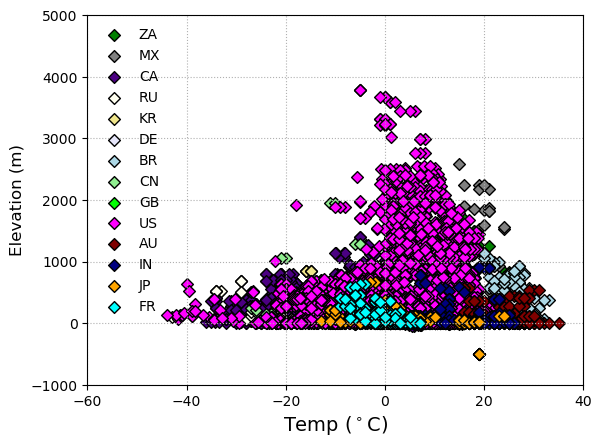

In [38]:

# Temperature in celsius

clr_dict = {
    'ZA': 'green',
    'MX': 'grey',
    'CA': 'indigo',
    'RU': 'ivory',
    'KR': 'khaki',
    'DE': 'lavender',
    'BR': 'lightblue',
    'CN': 'lightgreen',
    'GB': 'lime',
    'US': 'magenta',
    'AU': 'maroon',
    'IN': 'navy',
    'JP': 'orange',
    'FR': 'cyan',
}

fig, ax = plt.subplots()

for i in range(len(secs)):
    mask = df["country"]==secs[i]
    ax.scatter(df[mask]['tmpc'], df[mask]['elevation'], label=secs[i], color=clr_dict[secs[i]], edgecolor='k', marker='D')

ax.set_xlim(-60, 40)
ax.set_ylim(-1000, 5000)
ax.legend(loc='upper left',frameon=False, ncol=1, fontsize=10)
ax.set_xlabel(r'Temp ($^\circ$C)', fontsize=14)
ax.set_ylabel('Elevation (m)', fontsize=12)
ax.grid(ls=':')

#plt.savefig('Temp.pdf', bbox_inches='tight')

In [9]:
df = df.set_index('country')

In [10]:
selected_country = ['CA', 'DE', 'CN', 'AU', 'ZA']
subset = df.loc[selected_country]

tmpc: Temperature in degrees Celsius

In [12]:
df.tmpc

country
AU    18.0
AU    17.0
AU    23.0
AU    24.0
AU    27.0
      ... 
ZA    17.0
ZA    17.0
ZA    20.0
ZA    20.0
ZA    18.0
Name: tmpc, Length: 7787, dtype: float64

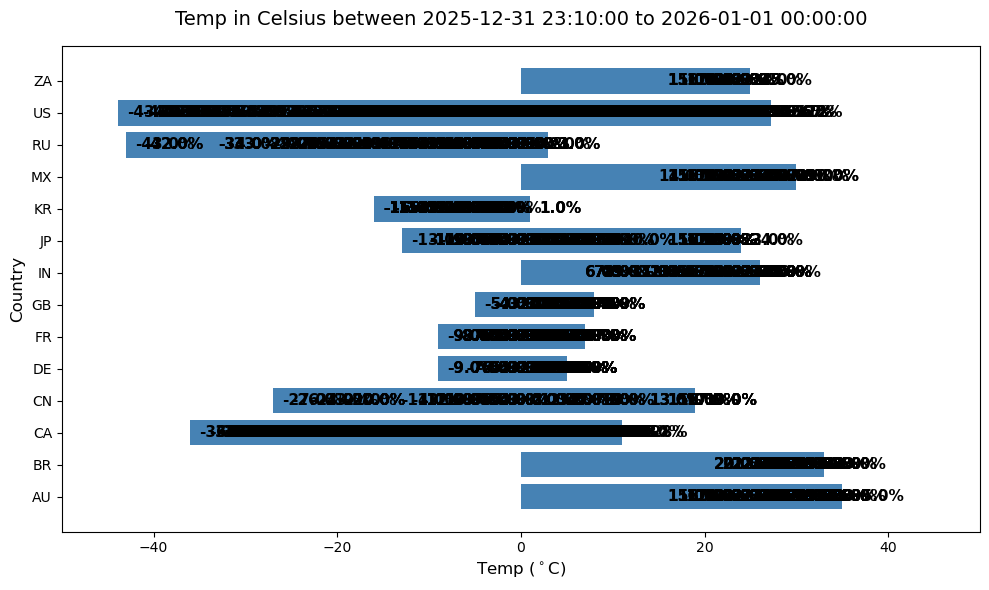

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(df['country'], df['tmpc'], color='#4682b4')

ax.set_title('Temp in Celsius between 2025-12-31 23:10:00 to 2026-01-01 00:00:00', fontsize=14, pad=15)
ax.set_xlabel('Temp ($^\circ$C)', fontsize=12)
ax.set_xlim(-50, 50)
ax.set_ylabel('Country', fontsize=12)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2, 
            f'{width}%', 
            va='center', ha='left', fontsize=11, fontweight='bold')

#ax.spines['top'].set_visible(False)
#ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('Temp.pdf', bbox_inches='tight')

In [42]:
from seaborn import barplot

ModuleNotFoundError: No module named 'seaborn'

In [41]:
from seaborn import barplot

fig, ax = subplots(figsize=(12, 6))

barplot(
    data=s.reset_index(),
    x='country', y='country', hue='valid',
    hue_order=years, palette='Blues',
    ax=ax
)

ax.legend(ncol=3, title='Year', loc='lower right', bbox_to_anchor=(1, 1))

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.yaxis.grid(color=ax.get_facecolor())
ax.set_xticklabels([t.get_text().title() for t in ax.get_xticklabels()]);
ax.set_xlabel('');
plt.tight_layout()
plt.savefig('Temp2.pdf', bbox_inches='tight')

ModuleNotFoundError: No module named 'seaborn'